In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# периодического АС


def Signal(A, Fs, Phi, t):
    # Входные переменные
    # A - амплитуда АС
    # Fs - частота АС
    # Phi - начальная фаза АС
    # t - вектор, содержащий
    # значения моментов времени,
    # в которые вычисляются
    # значения периодического АС

    return A * np.sin(2 * np.pi * Fs * t + Phi)

In [3]:
# Ячейка № 3

# задание функции, возвращающей
# значения координат узлов временной сетки
# и соответствующие значения ДС


def Signal_Discret(A, Fs, Phi, Nperiod, Fdmnless):
    # Входные переменные
    # A - амплитуда АС
    # Fs - частота АС в Гц
    # Phi - начальная фаза АС
    # Nperiod - количество периодов АС,
    #           укладывающихся на временном интервале [0,T0]
    #           (может быть нецелым числом)
    # Fdmnless - безразмерная частота ДС - отношение частоты АС
    #            к частоте дискретизации (1/T1),
    #            Fdmnless <  0.5

    # вычисление размерного значения
    # частоты дискретизации АС в Гц
    Fd = Fs / Fdmnless

    # вычисление периода
    # дискретизации АС в с
    Td = 1 / Fd

    # вычисление длины временного [0, T0],
    # на котором вычисляются значения ДС
    T0 = (1 / Fs) * Nperiod

    # задание координат временной сетки,
    # используемой для вычисления АС
    t = np.arange(0, T0, Td)

    # вычисление координат узлов
    # временной сетки и соответствующих
    # значений АС
    z = Signal(A, Fs, Phi, t)

    return t, z

In [4]:
# Ячейка № 4

# задание функции, вовращающей результат
# вычисления ДПФ, в соответствие c (7.107)
def DFT(x):
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    E = np.exp(-2j * np.pi * k * n / N)
    X = np.dot(E, x) / N
    return X

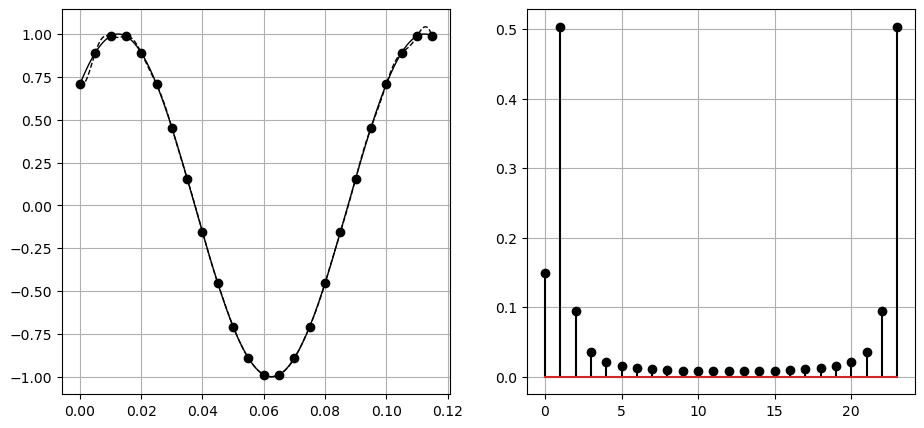

In [ ]:
# Ячейка № 5

# восстановление АС
# c помощью тригонометрического
# полинома, коэффициенты которого
# вычисляются в соответствие с ДПФ

# задание амплитуды АС
A = 1

# задание частоты АС в Гц
Fs = 10

# задание начальной фазы АС
Phi = np.pi / 4

# задание числа периодов АС,
# укладывающихся на интервале [0,T0]
Nperiod = 1.2

# вычисление значения T0
T0 = Nperiod / Fs

# задание значения
# безразмерной частоты ДС
# (безразмерная частота ДС -
# отношение частоты сигнала к
# к частоте дискретизации)
Fdmnless = 0.05

# задание числа узлов временной сетки,
# использованной для вычисления значений
# восстановленного АС
Np = 10**3

# вычисление значений ДС
t, z = Signal_Discret(A, Fs, Phi, Nperiod, Fdmnless)

# вычисление координат временной сетки,
# использованной для вычисления значений
# восстановленного АС
Time = np.linspace(0, t[len(t) - 1], Np, endpoint=True)

# вычисление значений АС
Za = Signal(A, Fs, Phi, Time)

# вычисление ДПФ
B = DFT(z)

# вычисление основной
# циклической частоты
# тригонометрического полинома
dt = t[1] - t[0]
Omega_0 = 2 * np.pi / (t[len(t) - 1] + dt)

# инициализация массива,
# используемого для хранения
# отсчетов восстановленного АС
P_tr = [complex(0, 0) for _ in range(len(Time))]

# восстановление АС
if len(z) % 2 != 0:
    # нечетное число отсчетов ДС

    # вычисление значения
    # максимальной степени
    # тригонометрического полинома
    N = round((len(z) - 1) / 2)

    # инициализация массива,
    # используемого для
    # хранения степеней переменной z
    # тригонометрического полинома (7.108)
    Z1 = np.zeros(len(z))

    # размещение степеней переменной z
    # в массиве Z1 в порядке
    # заданном в (7.108)
    N_tp1 = np.arange(0, N + 1, 1)
    N_tp2 = np.arange(-N, 0, 1)
    Z1 = np.hstack((N_tp1, N_tp2))

    # вычисление значений
    # восстанавливаемого АС
    for i in range(len(Time)):
        z0 = np.exp(1j * Omega_0 * Time[i])
        P_tr[i] = np.dot(B, z0**Z1)

else:
    # четное число узлов

    # вычисление значения
    # максимальной степени
    # тригонометрического полинома
    N = round(len(z) / 2)

    # инициализация массива,
    # используемого для
    # хранения степеней переменной z
    # тригонометрического полинома (7.108)
    Z1 = np.zeros(len(z))

    # размещение степеней переменной z
    # в массиве Z1 в порядке
    # заданном в (7.109)
    N_tp1 = np.arange(0, N + 1, 1)
    N_tp2 = np.arange(-N + 1, 0, 1)
    Z1 = np.hstack((N_tp1, N_tp2))

    # вычисление значений
    # восстанавливаемого АС
    for i in range(len(Time)):
        z0 = np.exp(1j * Omega_0 * Time[i])

        P_tr[i] = np.dot(B, z0**Z1)

# визуализация АС, ДС,
# восстановленного АС и
# коэффициентов ДПФ
fig = plt.figure(figsize=(11, 5))

# визуализация АС, ДС и
# восстановленного АС (слева)
ax = fig.add_subplot(121)
plt.plot(Time, Za, "-k", lw=1)
plt.plot(Time, np.real(P_tr), "--k", lw=1)
plt.plot(t, z, "o", color="k", lw=1)
plt.grid(True)

# создание массива, используемого
# для размещения номеров коэффициентов ДПФ
Ng = np.arange(0, len(B))

# визуализация коэффициентов ДПФ
ax = fig.add_subplot(122)
plt.stem(Ng, np.abs(B), "-k")
plt.grid(True)

plt.show()